# 03 - Similarity, Scaling and Distance Analysis

This notebook analyzes similarity and dissimilarity between Old School RuneScape players based on their cleaned Hiscores skill profiles.

The goal is to prepare the dataset for clustering by:

- creating a numeric feature matrix,
- scaling the attributes,
- calculating pairwise distances,
- identifying similar players,
- visualizing player profiles in two dimensions using PCA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

from scipy.spatial.distance import pdist, squareform

In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
IMAGES_DIR = PROJECT_ROOT / "images"

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

input_path = PROCESSED_DATA_DIR / "osrs_hiscores_cleaned.csv"

input_path

WindowsPath('C:/Projects/osrs-player-segmentation/data/processed/osrs_hiscores_cleaned.csv')

In [3]:
df = pd.read_csv(input_path)

df.head()

,player,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,...,construction,sailing,combat_score,gathering_score,production_score,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std
0,Obbyy,2376,99,99,99,99,99,99,99,99,...,99,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000
1,Obby Cape,2376,99,99,99,99,99,99,99,99,...,99,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000
2,Obby Apples,2278,99,99,99,99,99,99,99,99,...,99,1,99.000000,79.4,99.00,99.0,94.916667,99,1,20.004166
3,Obby Kenobi,1752,1,1,99,90,65,31,60,99,...,75,99,49.571429,91.4,82.25,72.5,73.000000,99,1,27.700259
4,obbE x,2376,99,99,99,99,99,99,99,99,...,99,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000


In [4]:
df.shape

(808, 34)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 808 entries, 0 to 807
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player               808 non-null    object 
 1   overall              808 non-null    int64  
 2   attack               808 non-null    int64  
 3   defence              808 non-null    int64  
 4   strength             808 non-null    int64  
 5   hitpoints            808 non-null    int64  
 6   ranged               808 non-null    int64  
 7   prayer               808 non-null    int64  
 8   magic                808 non-null    int64  
 9   cooking              808 non-null    int64  
 10  woodcutting          808 non-null    int64  
 11  fletching            808 non-null    int64  
 12  fishing              808 non-null    int64  
 13  firemaking           808 non-null    int64  
 14  crafting             808 non-null    int64  
 15  smithing             808 non-null    int

## 2. Feature matrix

Clustering and distance-based methods require a numeric data matrix.

In this project:

- each row represents one OSRS player,
- each column represents a numeric skill-related attribute,
- the `player` column is used only as an identifier and is not included in the feature matrix.

In [6]:
feature_columns = [column for column in df.columns if column != "player"]

X = df[feature_columns].copy()

X.head()

,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,woodcutting,...,construction,sailing,combat_score,gathering_score,production_score,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std
0,2376,99,99,99,99,99,99,99,99,99,...,99,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000
1,2376,99,99,99,99,99,99,99,99,99,...,99,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000
2,2278,99,99,99,99,99,99,99,99,99,...,99,1,99.000000,79.4,99.00,99.0,94.916667,99,1,20.004166
3,1752,1,1,99,90,65,31,60,99,99,...,75,99,49.571429,91.4,82.25,72.5,73.000000,99,1,27.700259
4,2376,99,99,99,99,99,99,99,99,99,...,99,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000


In [7]:
X.shape

(808, 33)

In [8]:
player_names = df["player"].values

player_names[:10]

array(['Obbyy', 'Obby Cape', 'Obby Apples', 'Obby Kenobi', 'obbE x',
       'Obby200', 'Obby z', 'obby', 'obbiz', 'Obby wang'], dtype=object)

## 3. Scaling

Distance-based methods are sensitive to the scale of the input variables.

If one attribute has a larger numeric range than another, it can dominate the distance calculation.

In this notebook, two scaling methods are tested:

- StandardScaler: transforms variables to zero mean and unit variance,
- MinMaxScaler: transforms variables into the [0, 1] range.

In [9]:
standard_scaler = StandardScaler()
X_standard_scaled = standard_scaler.fit_transform(X)

X_standard_scaled[:5]

array([[ 6.14504155e-01,  4.40211681e-01,  4.63407796e-01,
         3.57260115e-01,  3.61297906e-01,  3.75759403e-01,
         5.99304591e-01,  3.84684615e-01,  4.49984756e-01,
         5.06645928e-01,  5.29801575e-01,  5.37208190e-01,
         4.94779898e-01,  5.18563072e-01,  6.12545271e-01,
         5.30173046e-01,  5.69994777e-01,  6.37003970e-01,
         5.77362694e-01,  4.88321007e-01,  4.86118317e-01,
         6.81015495e-01,  6.32871674e-01,  6.16813156e-01,
         1.11907586e+00,  4.58372003e-01,  8.52707205e-01,
         5.98506413e-01,  5.68156219e-01,  6.40988395e-01,
         2.38644381e-01,  1.21874383e+00, -1.11720191e+00],
       [ 6.14504155e-01,  4.40211681e-01,  4.63407796e-01,
         3.57260115e-01,  3.61297906e-01,  3.75759403e-01,
         5.99304591e-01,  3.84684615e-01,  4.49984756e-01,
         5.06645928e-01,  5.29801575e-01,  5.37208190e-01,
         4.94779898e-01,  5.18563072e-01,  6.12545271e-01,
         5.30173046e-01,  5.69994777e-01,  6.37003970e-

In [10]:
minmax_scaler = MinMaxScaler()
X_minmax_scaled = minmax_scaler.fit_transform(X)

X_minmax_scaled[:5]

array([[1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 0.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 0.        ],
       [0.95875421, 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.    

In [11]:
df_standard_scaled = pd.DataFrame(
    X_standard_scaled,
    columns=feature_columns,
    index=df["player"]
)

df_minmax_scaled = pd.DataFrame(
    X_minmax_scaled,
    columns=feature_columns,
    index=df["player"]
)

df_standard_scaled.head()

,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,woodcutting,...,construction,sailing,combat_score,gathering_score,production_score,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std
player,,,,,,,,,,,,,,,,,,,,,
Obbyy,0.614504,0.440212,0.463408,0.35726,0.361298,0.375759,0.599305,0.384685,0.449985,0.506646,...,0.616813,1.119076,0.458372,0.852707,0.598506,0.568156,0.640988,0.238644,1.218744,-1.117202
Obby Cape,0.614504,0.440212,0.463408,0.35726,0.361298,0.375759,0.599305,0.384685,0.449985,0.506646,...,0.616813,1.119076,0.458372,0.852707,0.598506,0.568156,0.640988,0.238644,1.218744,-1.117202
Obby Apples,0.448611,0.440212,0.463408,0.35726,0.361298,0.375759,0.599305,0.384685,0.449985,0.506646,...,0.616813,-1.108722,0.458372,0.058775,0.598506,0.568156,0.464962,0.238644,-1.075662,0.757608
Obby Kenobi,-0.441794,-3.204850,-2.986294,0.35726,0.002271,-0.944469,-1.966795,-1.123425,0.449985,0.506646,...,-0.310702,1.119076,-1.562223,0.544856,-0.094980,-0.479791,-0.479830,0.238644,-1.075662,1.478894
obbE x,0.614504,0.440212,0.463408,0.35726,0.361298,0.375759,0.599305,0.384685,0.449985,0.506646,...,0.616813,1.119076,0.458372,0.852707,0.598506,0.568156,0.640988,0.238644,1.218744,-1.117202


## 4. Pairwise distance calculation

In this section, we calculate pairwise distances between players.

A smaller distance means that two players have more similar skill profiles.

We calculate:

- Euclidean distance,
- Manhattan distance.

In [12]:
euclidean_distances = pairwise_distances(
    X_standard_scaled,
    metric="euclidean"
)

df_euclidean = pd.DataFrame(
    euclidean_distances,
    index=player_names,
    columns=player_names
)

df_euclidean.head()

,Obbyy,Obby Cape,Obby Apples,Obby Kenobi,obbE x,Obby200,Obby z,obby,obbiz,Obby wang,...,rfr0sti,p3ych0,KDsBurnerAcc,kds141197,kdsnfmo,kdstudios,kdsuperhero,kdst,kdslo,kdsfdds
Obbyy,0.000000,0.000000,3.798833,8.165801,0.000000,0.426400,3.798833,9.126250,4.329426,0.000000,...,4.098768,20.769113,4.589193,4.224582,7.617614,12.114180,19.358090,19.970300,20.586947,21.246021
Obby Cape,0.000000,0.000000,3.798833,8.165801,0.000000,0.426400,3.798833,9.126250,4.329426,0.000000,...,4.098768,20.769113,4.589193,4.224582,7.617614,12.114180,19.358090,19.970300,20.586947,21.246021
Obby Apples,3.798833,3.798833,0.000000,7.721048,3.798833,3.372433,0.000000,7.874737,1.868381,3.798833,...,1.695252,20.285826,2.644075,4.279650,6.444579,11.256566,18.746807,19.386712,20.067419,20.837068
Obby Kenobi,8.165801,8.165801,7.721048,0.000000,8.165801,8.028026,7.721048,4.346484,7.337798,8.165801,...,7.381564,16.197982,6.651603,6.683868,6.366438,8.620571,14.945965,16.314543,16.115210,16.922710
obbE x,0.000000,0.000000,3.798833,8.165801,0.000000,0.426400,3.798833,9.126250,4.329426,0.000000,...,4.098768,20.769113,4.589193,4.224582,7.617614,12.114180,19.358090,19.970300,20.586947,21.246021


In [13]:
manhattan_distances = pairwise_distances(
    X_standard_scaled,
    metric="manhattan"
)

df_manhattan = pd.DataFrame(
    manhattan_distances,
    index=player_names,
    columns=player_names
)

df_manhattan.head()

,Obbyy,Obby Cape,Obby Apples,Obby Kenobi,obbE x,Obby200,Obby z,obby,obbiz,Obby wang,...,rfr0sti,p3ych0,KDsBurnerAcc,kds141197,kdsnfmo,kdstudios,kdsuperhero,kdst,kdslo,kdsfdds
Obbyy,0.000000,0.000000,7.532866,34.628976,0.000000,0.845526,7.532866,31.591761,14.405037,0.000000,...,13.157459,116.837202,17.606930,21.131712,39.874819,64.312141,107.261608,110.940506,114.774343,119.000664
Obby Cape,0.000000,0.000000,7.532866,34.628976,0.000000,0.845526,7.532866,31.591761,14.405037,0.000000,...,13.157459,116.837202,17.606930,21.131712,39.874819,64.312141,107.261608,110.940506,114.774343,119.000664
Obby Apples,7.532866,7.532866,0.000000,32.523869,7.532866,6.687340,0.000000,24.058895,6.872171,7.532866,...,6.111296,110.528703,10.474178,20.795309,32.492072,56.779276,99.728742,103.407640,107.777137,113.952550
Obby Kenobi,34.628976,34.628976,32.523869,0.000000,34.628976,34.283569,32.523869,18.326015,28.700627,34.628976,...,29.602898,84.875162,24.077003,25.298092,29.035616,42.213259,75.270999,87.479148,84.057070,88.968511
obbE x,0.000000,0.000000,7.532866,34.628976,0.000000,0.845526,7.532866,31.591761,14.405037,0.000000,...,13.157459,116.837202,17.606930,21.131712,39.874819,64.312141,107.261608,110.940506,114.774343,119.000664


## 5. Find the most similar players

For each selected player, we can find the closest other players based on Euclidean distance.

This helps demonstrate how distance-based similarity works on OSRS player profiles.

In [14]:
def find_similar_players(player_name, distance_matrix, top_n=5):
    """
    Find the most similar players based on a given distance matrix.
    The selected player itself is removed from the result.
    """
    if player_name not in distance_matrix.index:
        raise ValueError(f"Player '{player_name}' not found in the dataset.")
    
    distances = distance_matrix.loc[player_name].sort_values()
    distances = distances.drop(player_name)
    
    return distances.head(top_n)

In [15]:
example_player = df["player"].iloc[0]

find_similar_players(example_player, df_euclidean, top_n=5)

Cnhil           0.0
Cnr             0.0
Cn ii           0.0
VVonky Camel    0.0
VVintage        0.0
Name: Obbyy, dtype: float64

## 6. PCA visualization

The dataset contains many skill-related dimensions.

PCA is used to project the high-dimensional player profiles into two dimensions.

This makes it possible to visually inspect whether some players are naturally closer to each other.

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_standard_scaled)

df_pca = pd.DataFrame({
    "player": df["player"],
    "pca_1": X_pca[:, 0],
    "pca_2": X_pca[:, 1]
})

df_pca.head()

,player,pca_1,pca_2
0,Obbyy,-3.242032,-1.372130
1,Obby Cape,-3.242032,-1.372130
2,Obby Apples,-2.327813,1.708513
3,Obby Kenobi,2.606730,-1.208113
4,obbE x,-3.242032,-1.372130


In [17]:
explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.76730417, 0.06805159])

In [18]:
print(f"PCA component 1 explains {explained_variance[0]:.2%} of the variance.")
print(f"PCA component 2 explains {explained_variance[1]:.2%} of the variance.")
print(f"Together they explain {explained_variance.sum():.2%} of the variance.")

PCA component 1 explains 76.73% of the variance.
PCA component 2 explains 6.81% of the variance.
Together they explain 83.54% of the variance.


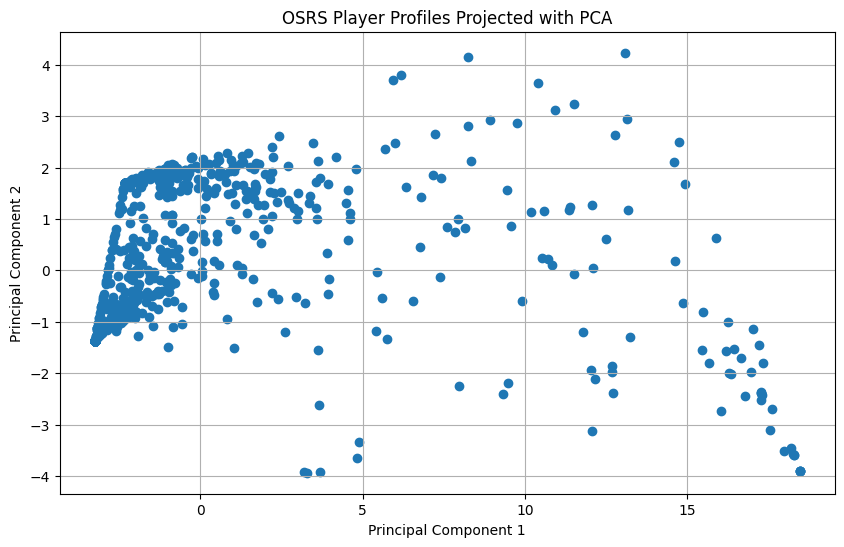

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(df_pca["pca_1"], df_pca["pca_2"])

plt.title("OSRS Player Profiles Projected with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

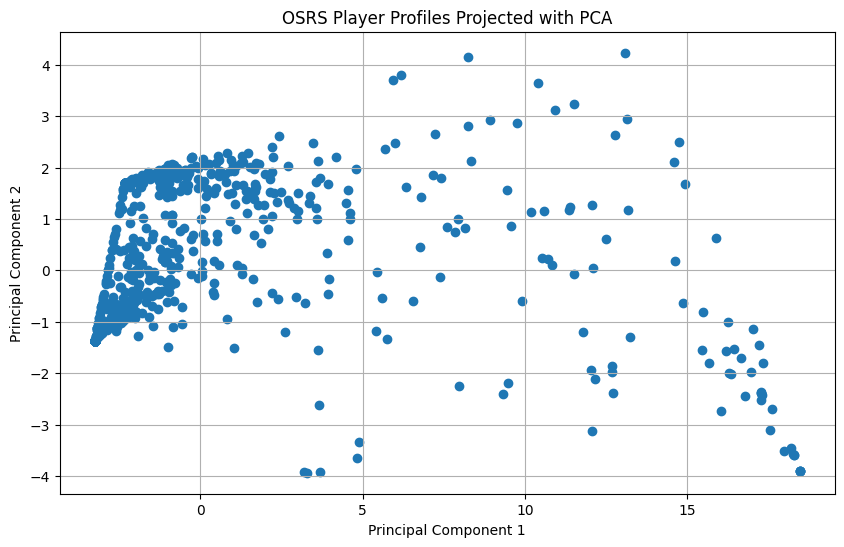

WindowsPath('C:/Projects/osrs-player-segmentation/images/pca_player_profiles.png')

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df_pca["pca_1"], df_pca["pca_2"])

plt.title("OSRS Player Profiles Projected with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

pca_plot_path = IMAGES_DIR / "pca_player_profiles.png"
plt.savefig(pca_plot_path, dpi=300, bbox_inches="tight")

plt.show()

pca_plot_path

## 7. Save PCA dataset

The PCA-transformed dataset is saved for later visualization and clustering interpretation.

In [21]:
pca_output_path = PROCESSED_DATA_DIR / "osrs_hiscores_pca.csv"

df_pca.to_csv(pca_output_path, index=False, encoding="utf-8")

pca_output_path

WindowsPath('C:/Projects/osrs-player-segmentation/data/processed/osrs_hiscores_pca.csv')

## Summary

In this notebook, the cleaned OSRS Hiscores dataset was prepared for distance-based analysis.

The main steps were:

- creating a numeric feature matrix,
- scaling features with StandardScaler and MinMaxScaler,
- calculating Euclidean and Manhattan distance matrices,
- finding the most similar players based on distance,
- reducing the dataset to two dimensions using PCA,
- saving the PCA visualization.

The next notebook will use the scaled feature matrix for clustering analysis.